In [2]:
# Importing necessary libraries 
# Core numerical and data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries for plots
import matplotlib.pyplot as plt
import seaborn as sns

# Explainability library for model interpretation
import shap

# Metrics for model evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
# loading the dataset and always inspect the first few rows to understand structuret
df = pd.read_csv('../data/raw/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Train-test split # Separate features (X) and target (y) 
# Stratified split ensures class distribution is preserved in train/test sets 
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Initialize Random Forest model 
# # n_estimators=200: number of trees # class_weight="balanced": handles class imbalance (important in fraud detection)
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

best_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
#
# Built-in Feature Importance
#
# Extract Feature Importance
# Train model first
best_model.fit(X_train, y_train)

# Extract feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)


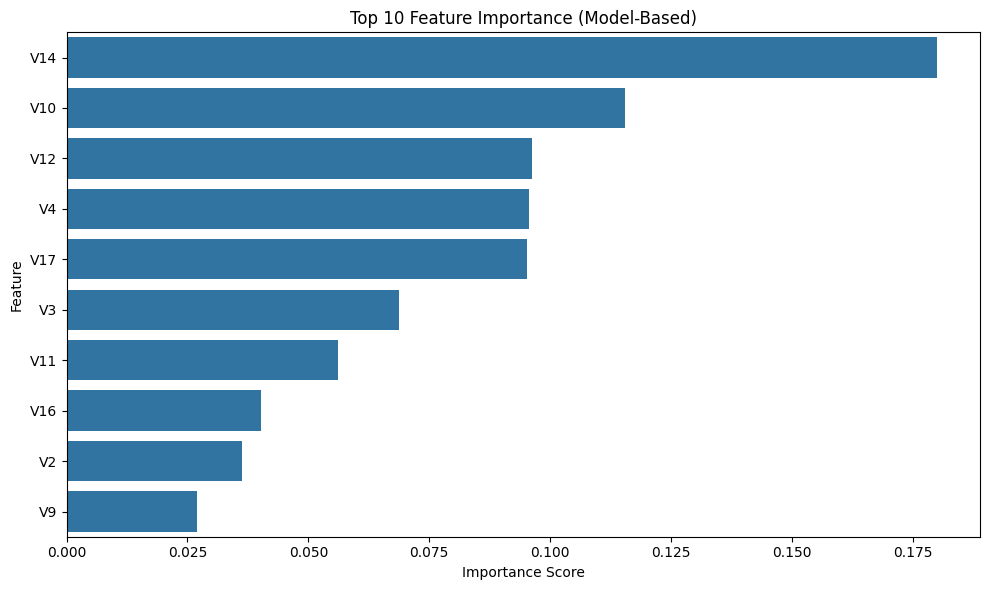

In [7]:
# Horizontal Bar Chart 
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Feature Importance (Model-Based)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


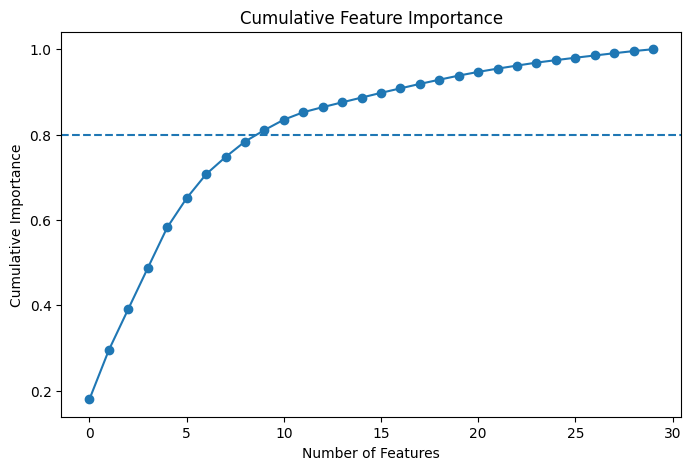

In [8]:
# Cumulative Feature Importance 
# Helps decide how many features explain most of the variance
feature_importance["cumulative"] = feature_importance["importance"].cumsum()

plt.figure(figsize=(8,5))
plt.plot(
    range(len(feature_importance)),
    feature_importance["cumulative"],
    marker='o'
)
plt.axhline(0.8, linestyle="--")
plt.title("Cumulative Feature Importance")
plt.xlabel("Number of Features")
plt.ylabel("Cumulative Importance")
plt.show()

In [9]:
#SHAP Analysis
# Sample first
sample_X = X_test.sample(100, random_state=42)
explainer = shap.TreeExplainer(best_model, feature_perturbation="tree_path_dependent")
shap_values = explainer.shap_values(sample_X, check_additivity=False)
shap.initjs()

In [10]:
## Inspect SHAP output types and shapes
print(type(shap_values))
print(type(shap_values[1]))
print("SHAP shape:", np.array(shap_values[1]).shape)
print("X_test shape:", X_test.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
SHAP shape: (30, 2)
X_test shape: (56962, 30)


In [11]:
# Re-splitting (redundant here, but ensures consistency if code is rerun)
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)  
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

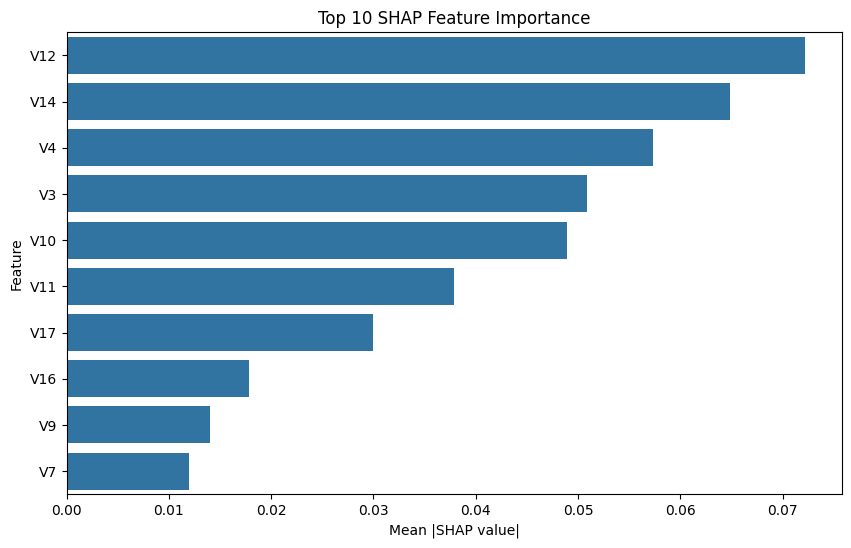

In [12]:
# Select SHAP values for class 1
shap_class_1 = shap_values[:, :, 1]

# Mean absolute SHAP per feature
shap_importance = np.abs(shap_class_1).mean(axis=0)

# Build DataFrame
shap_df = pd.DataFrame({
    "feature": sample_X.columns,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=shap_df.head(10),
    x="shap_importance",
    y="feature"
)
plt.title("Top 10 SHAP Feature Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.show()


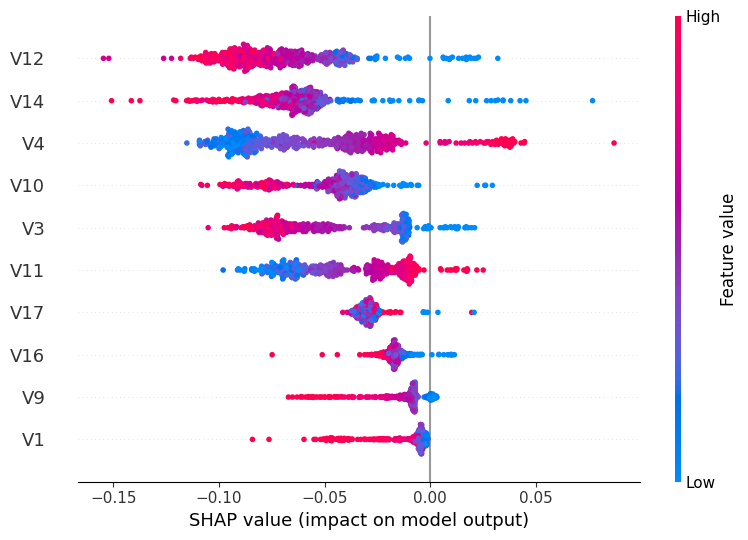

In [13]:
# explainer = shap.Explainer(model, X_train)
X_test_sample = X_test.sample(500, random_state=42)
shap_values_sample = explainer(X_test_sample)

shap_array = (
    shap_values_sample.values
    if hasattr(shap_values_sample, "values")
    else shap_values_sample
)

shap.summary_plot(
    shap_array[:, :, 1],
    X_test_sample,
    max_display=10
)

In [ ]:
# For binary classification, class 1
shap_class_1 = shap_values[:, :, 1]  

# Mean absolute SHAP per feature
shap_importance = np.abs(shap_class_1).mean(axis=0)  

In [16]:
shap_df = pd.DataFrame({
    "feature": X_test.columns,
    "shap_importance": shap_importance
}).sort_values(by="shap_importance", ascending=False)

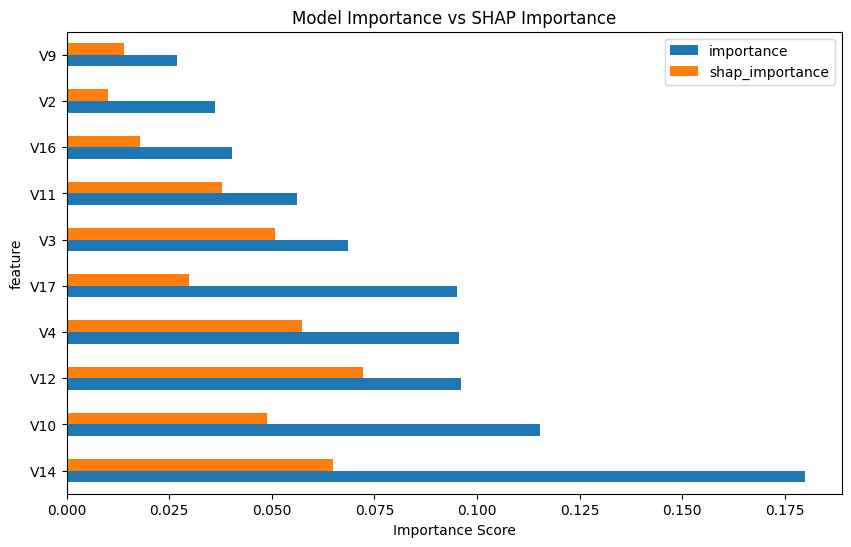

In [17]:
compare_df = feature_importance.merge(shap_df, on="feature").head(10)

compare_df.set_index("feature")[["importance", "shap_importance"]].plot(
    kind="barh",
    figsize=(10,6)
)
plt.title("Model Importance vs SHAP Importance")
plt.xlabel("Importance Score")
plt.show()

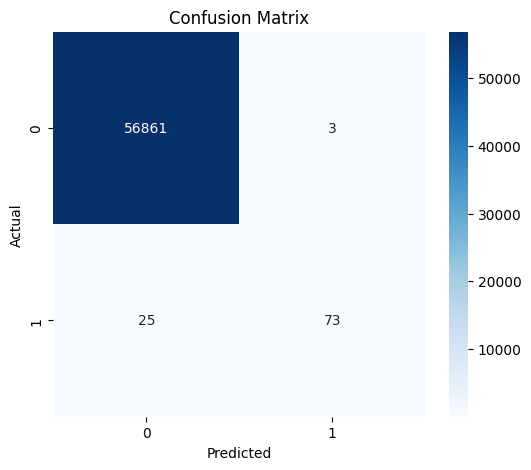

In [18]:
# Model Prediction and Confusion Matrix
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [19]:
# Collect results for interpretation
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred

tp_idx = results[(results.actual == 1) & (results.predicted == 1)].index[0]
fp_idx = results[(results.actual == 0) & (results.predicted == 1)].index[0]
fn_idx = results[(results.actual == 1) & (results.predicted == 0)].index[0]

In [ ]:
# For class 1 (fraud)
shap_class_1 = shap_values[:, :, 1]  

In [ ]:
# Sample 100 rows from X_test for SHAP
X_test_sample = X_test.sample(100, random_state=42)

shap_values_sample = explainer(X_test_sample)
shap_class_1 = shap_values_sample[:, :, 1]  

row_idx = 0
tp_sample_idx = X_test_sample.index[row_idx]
shap_row = shap_class_1[row_idx]

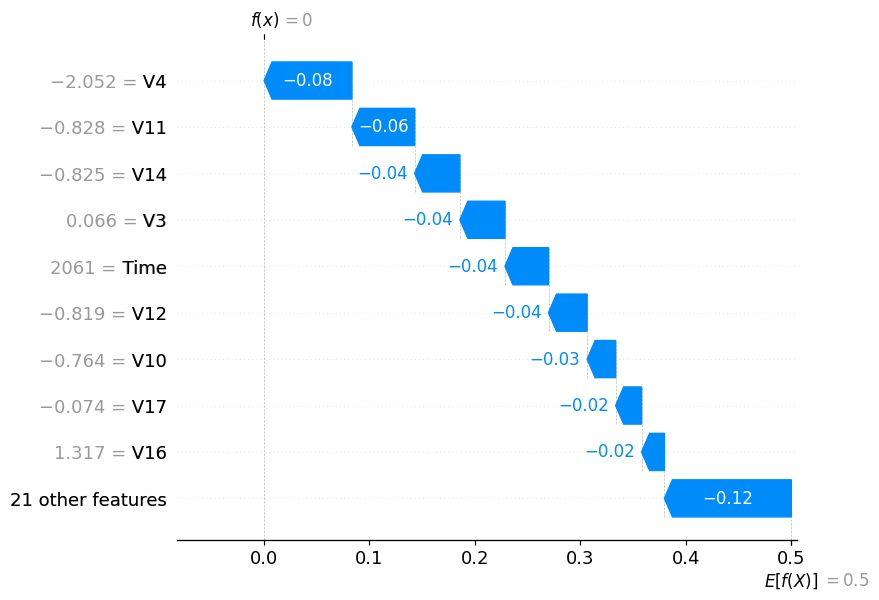

In [32]:
# TRUE POSITIVE – Waterfall Plot 
# # Shows how each feature contributed to a correct fraud detection
shap.plots.waterfall(
    shap.Explanation(
        values=shap_row,
        base_values=explainer.expected_value[1],
        data=X_test.loc[tp_idx],
        feature_names=X_test.columns
    )
)

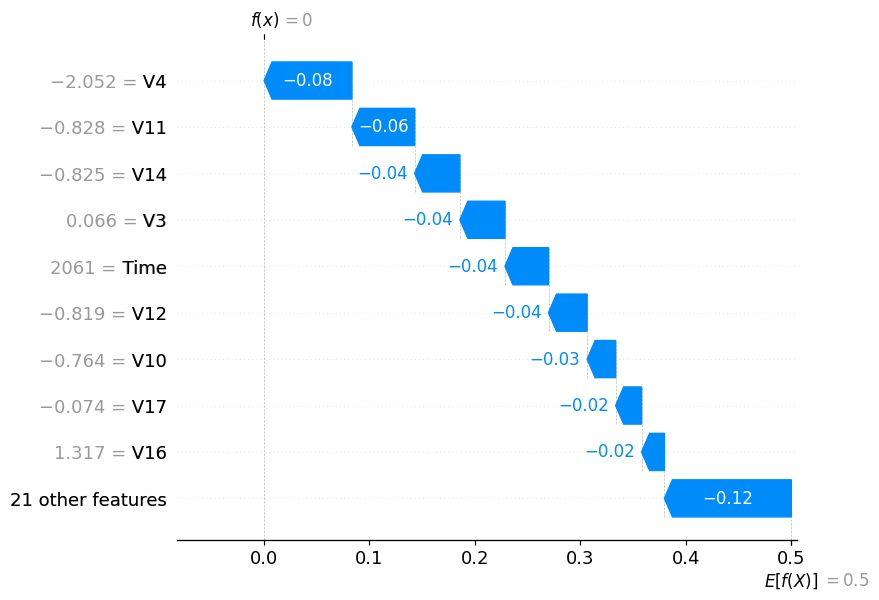

In [36]:
# FALSE POSITIVE – Waterfall Plot # Explains why the model incorrectly flagged a normal transaction as fraud
X_test_sample = X_test.sample(100, random_state=42)
shap_values_sample = explainer(X_test_sample)
shap_class_1 = shap_values_sample[:, :, 1]  

fp_sample_idx = X_test_sample.index[0]  
row_idx = 0  

shap.plots.waterfall(
    shap.Explanation(
        values=shap_class_1[row_idx],
        base_values=explainer.expected_value[1],
        data=X_test_sample.loc[fp_sample_idx],
        feature_names=X_test.columns
    )
)

In [39]:
# Sample 100 rows for faster SHAP computation
X_test_sample = X_test.sample(100, random_state=42)
shap_values_sample = explainer(X_test_sample)

shap_class_1 = shap_values_sample[:, :, 1]  

# Example: pick first false negative in sample
fn_sample_idx = X_test_sample.index[0]  
row_idx = 0  

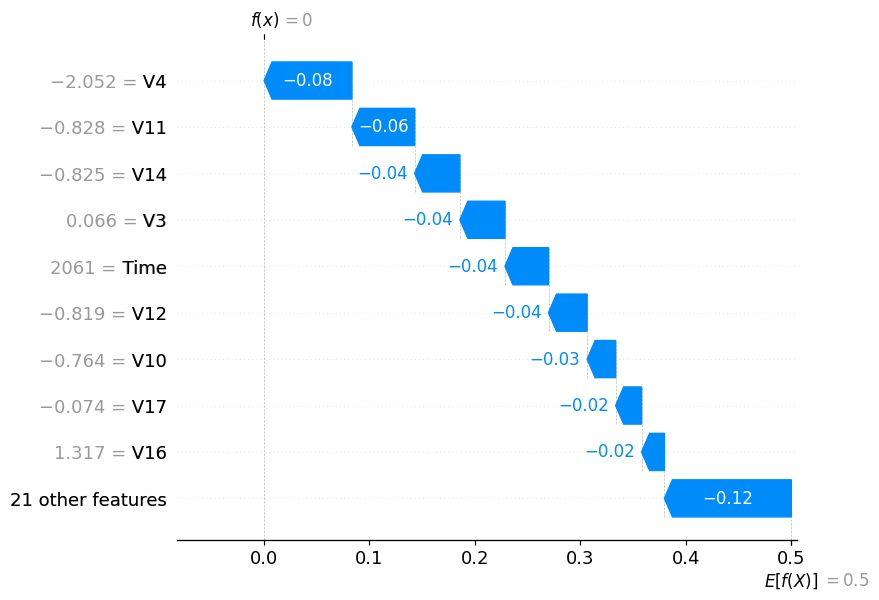

In [41]:
# FALSE NEGATIVE – Waterfall Plot
# Explains why the model missed a fraudulent transaction
shap.plots.waterfall(
    shap.Explanation(
        values=shap_class_1[row_idx],
        base_values=explainer.expected_value[1],
        data=X_test_sample.loc[fn_sample_idx],
        feature_names=X_test.columns
    )
)
